# Intelligent Student Performance Decision Support System

<h5><strong>Dataset:</strong></h5> Student Performance Dataset - This dataset contains comprehensive information on 2,392 high school students, detailing their demographics, study habits, parental involvement, extracurricular activities, and academic performance. The target variable, GradeClass, classifies students' grades into distinct categories, providing a robust dataset for educational research, predictive modeling, and statistical analysis.<br>
<h5><strong>Dataset link:</strong></h5> https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset

<h5><strong>Imports</strong></h5>

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

DATA_PATH = 'data/Student_performance_data__.csv'
MODELS_DIR = 'models'
OUT_DIR = 'outputs'

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

GRADE_LABELS = {
    0: "A",
    1: "B",
    2: "C",
    3: "D",
    4: "F"
}

<h5><strong>Data Inspect</strong></h5>

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
df_raw.head(3)

(2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0


In [3]:
print(df_raw.isnull().sum())
print()
print(df_raw.dtypes)

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object


<h5><strong>EDA</strong></h5>

GradeClass: 0=A, 1=B, 2=C, 3=D, 4=F. GPA is continuous(0.0 - 4.0)

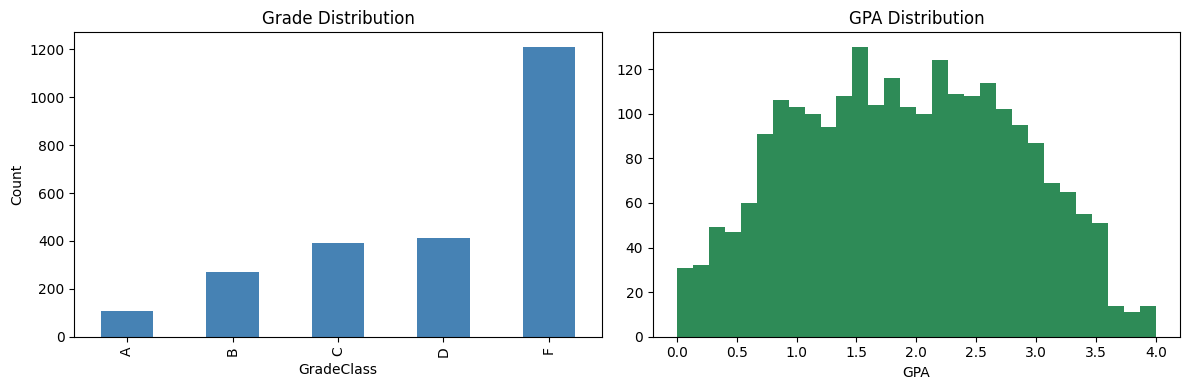

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_raw['GradeClass'].map(GRADE_LABELS).value_counts().reindex(["A", "B", "C", "D", "F"]).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Grade Distribution')
axes[0].set_ylabel('Count')

axes[1].hist(df_raw['GPA'], bins=30, color='seagreen')
axes[1].set_title('GPA Distribution')
axes[1].set_xlabel('GPA')

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/grade_gpa_distribution.png", dpi=150)
plt.show()

<strong>Observation:</strong>
GradeClass is heavily inbalanced as F(gradeclass=4) makes up ~50% of the students while A(gradeclass=0) is roughly only ~4-5%.This is confirmed by GPA range distribution. This means classification evaluation must rely on macro averaged metrics not just accuracy.

In [5]:
print(df_raw.groupby('GradeClass')['GPA'].describe().agg(['min', 'max', 'mean', 'count']))

        count      mean       std       min       25%       50%       75%  \
min     107.0  1.208041  0.361295  0.000000  0.816809  1.247482  1.626695   
max    1211.0  3.102942  0.946137  0.557549  3.055254  3.548460  3.694455   
mean    478.4  2.437589  0.572936  0.154424  2.229718  2.582765  2.776725   
count     5.0  5.000000  5.000000  5.000000  5.000000  5.000000  5.000000   

            max  
min    3.572945  
max    4.000000  
mean   3.830026  
count  5.000000  


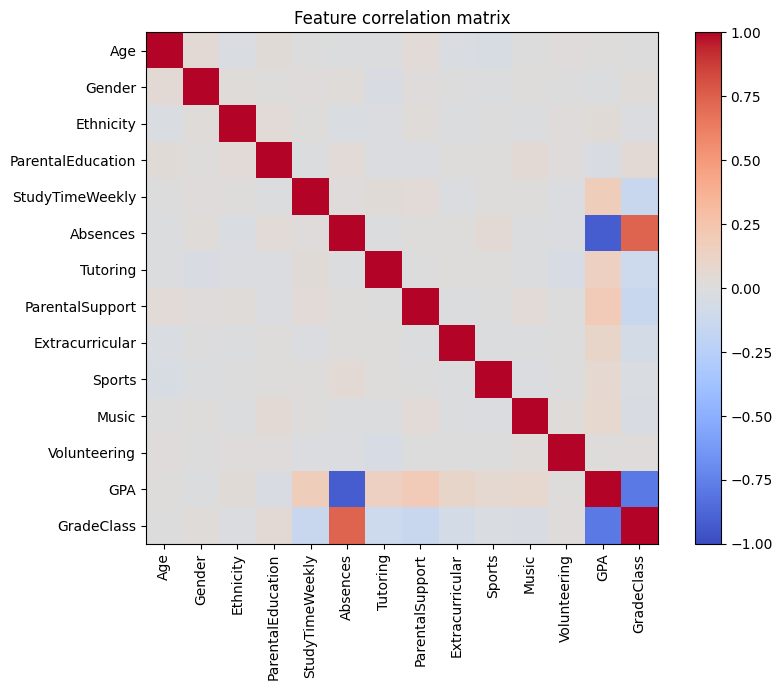

In [6]:
corr = df_raw.drop(columns=['StudentID']).corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
plt.colorbar(im)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_correlation.png", dpi=150)
plt.show()

<h5><strong>Feature Engineering</strong></h5>

Structured data layer — the tabular features below will feed the ML models directly.

In [7]:
FEATURE_COL = [
    "Age", "Gender", "Ethnicity", "ParentalEducation", "StudyTimeWeekly",
    "Absences", "Tutoring", "ParentalSupport", "Extracurricular",
    "Sports", "Music", "Volunteering"
]

In [8]:
def engineer_features(df):
    df = df.copy()
    df["AttendanceRate"] = 1 - (df["Absences"] / 180)   # assuming 180 school days in a year
    df["EngagementScore"] = (
        df["Extracurricular"] + df["Sports"] + df["Music"] + df["Volunteering"]
    )
    return df

Rule-based layer — IF-THEN domain rules that translate a student's raw profile into explainable risk flags and recommendations, independent of the ML "black box". Implemented in assess_risk_rules() / generate_recommendation() below, and will be reused as is inside the deployed app.py.

In [9]:
def assess_risk_rules(student):
    flags = []
    if student["Absences"] > 20 and student["StudyTimeWeekly"] < 5:
        flags.append(("High Risk: chronic absence + low study time",
                       "Immediate advisor meeting; structured study plan + attendance monitoring."))
    if student["Tutoring"] == 0 and student["ParentalSupport"] <= 1:
        flags.append(("Low support network",
                       "Recommend tutoring enrollment; notify guardians about support resources."))
    if student["Extracurricular"] == 0 and student["Absences"] > 15:
        flags.append(("Disengagement signal",
                       "Recommend counseling check-in and engagement activities."))
    if student["StudyTimeWeekly"] < 3:
        flags.append(("Very low study time",
                       "Introduce a weekly study-hours goal and progress check-ins."))
    if not flags:
        flags.append(("No major risk flags", "Continue current support; monitor periodically."))
    return flags

In [10]:
def generate_recommendation(student, predicted_gpa, predicted_grade_label):
    flags = assess_risk_rules(student)
    if predicted_grade_label in ("F", "D"):
        overall = "HIGH PRIORITY - intervention recommended"
    elif predicted_grade_label == "C":
        overall = "MODERATE - monitor closely"
    else:
        overall = "LOW PRIORITY - on track"
    return {
        "predicted_gpa": round(float(predicted_gpa), 2),
        "predicted_grade": predicted_grade_label,
        "overall_status": overall,
        "risk_flags": flags,
    }

In [11]:
demo = {
    "StudyTimeWeekly": 2.5, 
    "Absences": 25, 
    "Tutoring": 0, 
    "ParentalSupport": 1, 
    "Extracurricular": 0
}
generate_recommendation(
    demo, 
    predicted_gpa=1.1, 
    predicted_grade_label="F"
)

{'predicted_gpa': 1.1,
 'predicted_grade': 'F',
 'overall_status': 'HIGH PRIORITY - intervention recommended',
 'risk_flags': [('High Risk: chronic absence + low study time',
   'Immediate advisor meeting; structured study plan + attendance monitoring.'),
  ('Low support network',
   'Recommend tutoring enrollment; notify guardians about support resources.'),
  ('Disengagement signal',
   'Recommend counseling check-in and engagement activities.'),
  ('Very low study time',
   'Introduce a weekly study-hours goal and progress check-ins.')]}

<h5><strong>PREPROCESSING & TRAIN/TEST SPLIT</strong></h5>

Pre-processing

In [12]:
df = engineer_features(df_raw.drop(columns=['StudentID']))
feature_cols = FEATURE_COL + ["AttendanceRate", "EngagementScore"]

X = df[feature_cols]
y_clf = df["GradeClass"].astype(int)
y_reg = df["GPA"].astype(float)

In [13]:
# Classification split (stratified, since classes are imbalanced)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

In [14]:
# Regression split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

In [15]:
# Classification scalers
clf_scaler = StandardScaler().fit(Xc_train)
Xc_train_s, Xc_test_s = clf_scaler.transform(Xc_train), clf_scaler.transform(Xc_test)

In [16]:
# Regression scalers
reg_scaler = StandardScaler().fit(Xr_train)
Xr_train_s, Xr_test_s = reg_scaler.transform(Xr_train), reg_scaler.transform(Xr_test)

In [17]:
joblib.dump(clf_scaler, f"{MODELS_DIR}/clf_scaler.joblib")
joblib.dump(reg_scaler, f"{MODELS_DIR}/reg_scaler.joblib")
joblib.dump(feature_cols, f"{MODELS_DIR}/feature_cols.joblib")

print("Classification:", Xc_train_s.shape, Xc_test_s.shape)
print("Regression:", Xr_train_s.shape, Xr_test_s.shape)

Classification: (1913, 14) (479, 14)
Regression: (1913, 14) (479, 14)


Classification predicion

Logistic Regression, Random Forest, SVM (RBF), K-Nearest Neighbors, XGBoost.

In [18]:
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, 
        max_depth=10, 
        random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel="rbf", 
        probability=True, 
        random_state=42
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "XGBoost": XGBClassifier(
        n_estimators=300, 
        max_depth=5, 
        learning_rate=0.05,
        eval_metric="mlogloss", 
        random_state=42
    ),
}

n_classes = len(GRADE_LABELS)
yc_test_bin = label_binarize(yc_test, classes=list(range(n_classes)))

clf_results = []
confusion_matrices = {}

for name, model in clf_models.items():
    model.fit(Xc_train_s, yc_train)
    y_pred = model.predict(Xc_test_s)

    acc = accuracy_score(yc_test, y_pred)
    prec = precision_score(yc_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(yc_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(yc_test, y_pred, average="macro", zero_division=0)

    try:
        y_proba = model.predict_proba(Xc_test_s)
        auc = roc_auc_score(yc_test_bin, y_proba, average="macro", multi_class="ovr")
    except Exception:
        auc = np.nan

    clf_results.append({
        "Model": name, 
        "Accuracy": round(acc,4), 
        "Precision(macro)": round(prec,4),
        "Recall(macro)": round(rec,4), 
        "F1(macro)": round(f1,4),
        "ROC-AUC(macro)": round(auc,4) if not np.isnan(auc) else "N/A"
    })

    confusion_matrices[name] = confusion_matrix(yc_test, y_pred)
    joblib.dump(model, f"{MODELS_DIR}/clf_{name.replace(' ','_').replace('(','').replace(')','')}.joblib")

clf_results_df = pd.DataFrame(clf_results).sort_values("F1(macro)", ascending=False)
clf_results_df.to_csv(f"{OUT_DIR}/classification_results.csv", index=False)
clf_results_df


,Model,Accuracy,Precision(macro),Recall(macro),F1(macro),ROC-AUC(macro)
2,SVM (RBF),0.7161,0.6508,0.5433,0.5544,0.8683
4,XGBoost,0.7056,0.5714,0.5443,0.5502,0.8514
1,Random Forest,0.7161,0.5959,0.5431,0.5475,0.8588
0,Logistic Regression,0.7265,0.5725,0.5329,0.5398,0.8687
3,K-Nearest Neighbors,0.6075,0.4591,0.3717,0.3723,0.7879


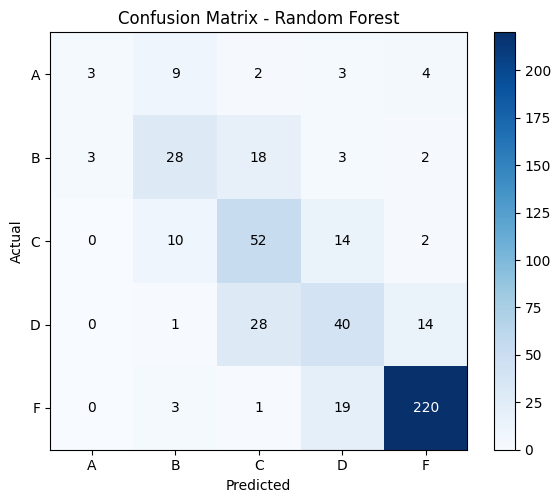

In [19]:
fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrices["Random Forest"]
labels = ["A","B","C","D","F"]

im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(5)); ax.set_xticklabels(labels)
ax.set_yticks(range(5)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Random Forest")

for i in range(5):
    for j in range(5):
        ax.text(j, i, int(cm[i,j]), ha="center", va="center",
                 color="white" if cm[i,j] > cm.max()/2 else "black")
        
plt.colorbar(im)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix_rf.png", dpi=150)
plt.show()

Regression prediction

Linear Regression, Random Forest Regressor, SVR (RBF), XGBoost Regressor, Gradient Boosting.

In [20]:
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    "SVR (RBF)": SVR(kernel="rbf", C=1.0, epsilon=0.1),
    "XGBoost Regressor": XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
}

reg_results = []
for name, model in reg_models.items():
    model.fit(Xr_train_s, yr_train)
    y_pred = model.predict(Xr_test_s)
    rmse = np.sqrt(mean_squared_error(yr_test, y_pred))
    mae = mean_absolute_error(yr_test, y_pred)
    r2 = r2_score(yr_test, y_pred)
    reg_results.append({
        "Model": name, 
        "RMSE": round(rmse,4), 
        "MAE": round(mae,4), 
        "R2": round(r2,4)
    })
    joblib.dump(model, f"{MODELS_DIR}/reg_{name.replace(' ','_').replace('(','').replace(')','')}.joblib")

reg_results_df = pd.DataFrame(reg_results).sort_values("R2", ascending=False)
reg_results_df.to_csv(f"{OUT_DIR}/regression_results.csv", index=False)
reg_results_df

,Model,RMSE,MAE,R2
0,Linear Regression,0.1966,0.1553,0.9532
4,Gradient Boosting,0.2088,0.1641,0.9473
3,XGBoost Regressor,0.2178,0.1743,0.9426
2,SVR (RBF),0.2318,0.1828,0.9350
1,Random Forest Regressor,0.2383,0.1864,0.9313


Cross-validation 5 folds

In [21]:
X_full_scaled = StandardScaler().fit_transform(X)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_cv_results = []

for name, model in clf_models.items():
    scores = cross_val_score(model, X_full_scaled, y_clf, cv=skf, scoring="f1_macro")
    clf_cv_results.append({
        "Model": name, 
        "CV F1(macro) mean": round(scores.mean(),4),
        "CV F1(macro) std": round(scores.std(),4)
    })
    
clf_cv_df = pd.DataFrame(clf_cv_results).sort_values("CV F1(macro) mean", ascending=False)
clf_cv_df.to_csv(f"{OUT_DIR}/classification_cv_results.csv", index=False)
clf_cv_df

,Model,CV F1(macro) mean,CV F1(macro) std
1,Random Forest,0.5636,0.0205
4,XGBoost,0.5606,0.0261
2,SVM (RBF),0.5165,0.0359
0,Logistic Regression,0.5162,0.0297
3,K-Nearest Neighbors,0.4146,0.0369


In [ ]:
kf = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=42

)

reg_cv_results = []
for name, model in reg_models.items():
    scores = cross_val_score(model, X_full_scaled, y_reg, cv=kf, scoring="r2")
    reg_cv_results.append({
        "Model": name, 
        "CV R2 mean": round(scores.mean(),4),
        "CV R2 std": round(scores.std(),4)
    })
    
reg_cv_df = pd.DataFrame(reg_cv_results).sort_values("CV R2 mean", ascending=False)
reg_cv_df.to_csv(f"{OUT_DIR}/regression_cv_results.csv", index=False)
reg_cv_df

,Model,CV R2 mean,CV R2 std
0,Linear Regression,0.9534,0.0038
4,Gradient Boosting,0.9479,0.0043
3,XGBoost Regressor,0.9426,0.0051
2,SVR (RBF),0.9389,0.0049
1,Random Forest Regressor,0.9334,0.0037
